# 🏛️ Malayalam Government Orders NER Model (XLM-RoBERTa)

Welcome to the **Named Entity Recognition (NER)** pipeline! This notebook implements the complete end-to-end pipeline:
1. **Auto-Labeling (Weak Supervision)**: Parse Malayalam markdown documents to automatically extract the complete GO Reference identifier (including prefix), generating separate `train.json`, `val.json`, and `test.json` splits at the document-level to ensure zero data leakage.
2. **Data Preparation**: Tokenize the text using XLM-RoBERTa's tokenizer and align the character spans of our entities to the subword tokens using BIO tagging.
3. **Model Fine-Tuning**: Unfreeze the top 1 encoder layer of XLM-RoBERTa and train on CPU for 20 epochs, saving the trained model.
4. **Interactive Extraction**: Extract the GO Reference from unseen text using our deep-learning pure NER model without any post-processing regex rules.
5. **Test Split Evaluation**: Run evaluation on the unseen test split documents to measure model accuracy, precision, recall, and F1 score, and display a visual confusion matrix.

## 📂 Stage 1: Automated Dataset Labeling
This cell reads every Malayalam markdown file in the folder, parses the header lines, and extracts the G.O. Reference (including prefix) using robust pattern matching to compile the training dataset `train.json`, validation dataset `val.json`, and testing dataset `test.json` with a 70/15/15 ratio.

In [3]:
import os
import json
import re
import random

# Ensure working directory is aligned to mal_geo_ner folder
if os.path.basename(os.getcwd()) != 'mal_geo_ner' and os.path.exists('mal_geo_ner'):
    os.chdir('mal_geo_ner')
print('Working directory:', os.getcwd())

def auto_label_dataset(directory='.'):
    # Gather files
    md_files = sorted([f for f in os.listdir(directory) if f.endswith('.md')])
    md_files = [f for f in md_files if not f.startswith('Project_Report') and f != 'README.md']
    
    # Malayalam G.O. Number pattern including full prefix (സ.ഉ. / G.O. / etc.)
    go_pattern = r'((?:സ\.?\s*ഉ\.?|G\.?\s*O\.?)\s*(?:\([^)]*\))?\s*(?:No\.|No:|No|നം\.?|നം:|നമ്പർ|നന്പർ)?\s*[:.,-]?\s*\d+(?:\s*/\s*[\d()]+)*\s*/\s*[\u0D00-\u0D7FA-Za-z0-9()-]+(?:\.[\u0D00-\u0D7FA-Za-z0-9()-]+)*)'
    
    random.seed(42)
    shuffled_files = md_files.copy()
    random.shuffle(shuffled_files)
    
    # Split files 70% train, 15% val, 15% test
    train_idx = int(len(shuffled_files) * 0.70)
    val_idx = train_idx + int(len(shuffled_files) * 0.15)
    
    train_files = shuffled_files[:train_idx]
    val_files = shuffled_files[train_idx:val_idx]
    test_files = shuffled_files[val_idx:]
    
    def process_files(files_list):
        data = []
        for f_name in files_list:
            path = os.path.join(directory, f_name)
            with open(path, 'r', encoding='utf-8') as f:
                content = f.read()
            
            lines = content.split('\n')
            
            go_text = None
            for line in lines[:30]:
                cleaned = line.replace('#', '').replace('*', '').replace('_', '').strip()
                # Stop scanning if reference section is reached
                if 'പരാമർശം' in cleaned or 'പരാമർശങ്ങൾ' in cleaned:
                    break
                m = re.search(go_pattern, cleaned)
                if m:
                    go_text = m.group(1).strip()
                    break
            
            if not go_text:
                continue
                
            pos_lines = []
            neg_lines = []
            
            for line in lines[:30]:
                line_clean = line.replace('#', ' ').replace('*', ' ').replace('_', ' ').replace('\\', ' ')
                line_clean = re.sub(r'\s+', ' ', line_clean).strip()
                if not line_clean or len(line_clean) < 4:
                    continue
                    
                entities = []
                is_reference_line = any(x in line_clean.upper() for x in ['READ', 'LETTER', 'U.O.', 'WP(C)', 'JUDGEMENT', 'REFERENCE']) or 'പരാമർശം' in line_clean or 'പരാമർശങ്ങൾ' in line_clean
                
                if go_text and not is_reference_line:
                    m = re.search(re.escape(go_text), line_clean, re.IGNORECASE)
                    if m:
                        entities.append([m.group(0), 'GO_NUMBER'])
                        
                if entities:
                    pos_lines.append({
                        'text': line_clean,
                        'entities': entities
                    })
                else:
                    if len(line_clean) > 8:
                        neg_lines.append({
                            'text': line_clean,
                            'entities': []
                        })
                        
            data.extend(pos_lines)
            if neg_lines:
                data.extend(random.sample(neg_lines, min(len(neg_lines), 2)))
                
        return data

    train_data = process_files(train_files)
    val_data = process_files(val_files)
    test_data = process_files(test_files)
    
    with open('train.json', 'w', encoding='utf-8') as f:
        json.dump(train_data, f, indent=4, ensure_ascii=False)
    with open('val.json', 'w', encoding='utf-8') as f:
        json.dump(val_data, f, indent=4, ensure_ascii=False)
    with open('test.json', 'w', encoding='utf-8') as f:
        json.dump(test_data, f, indent=4, ensure_ascii=False)
        
    print(f'Generated dataset splits with zero document leakage:')
    print(f'Training split: {len(train_data)} lines (from {len(train_files)} files)')
    print(f'Validation split: {len(val_data)} lines (from {len(val_files)} files)')
    print(f'Testing split: {len(test_data)} lines (from {len(test_files)} files)')
    return train_data, val_data, test_data

train_examples, val_examples, test_examples = auto_label_dataset()


Working directory: c:\Users\adnan\Desktop\geo_ner\mal_geo_ner
Generated dataset splits with zero document leakage:
Training split: 635 lines (from 204 files)
Validation split: 134 lines (from 43 files)
Testing split: 137 lines (from 45 files)


## ⚙️ Stage 2: Imports and System Configuration
We import PyTorch, Hugging Face `transformers`, `datasets`, and check if we are training on CPU or GPU.

In [4]:
import os
import json
import torch
import random
import numpy as np
from transformers import (
    AutoTokenizer, 
    AutoModelForTokenClassification, 
    TrainingArguments, 
    Trainer,
    DataCollatorForTokenClassification
)
from datasets import Dataset

print('PyTorch Version:', torch.__version__)
print('CUDA Available:', torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Training on Device:', device)

c:\Users\adnan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.sparse import csr_matrix, issparse



PyTorch Version: 2.11.0+cpu
CUDA Available: False
Training on Device: cpu


## 📂 Stage 3: Load Dataset Splits
We load the generated `train.json` file and split it into training (70%), validation (15%), and testing (15%) subsets.

In [5]:
with open('train.json', 'r', encoding='utf-8') as f:
    train_examples = json.load(f)
with open('val.json', 'r', encoding='utf-8') as f:
    val_examples = json.load(f)
with open('test.json', 'r', encoding='utf-8') as f:
    test_examples = json.load(f)

print(f'Train size: {len(train_examples)} | Validation size: {len(val_examples)} | Test size: {len(test_examples)}')
print('\nSample train example:')
print(json.dumps(train_examples[0], indent=2, ensure_ascii=False))


Train size: 635 | Validation size: 134 | Test size: 137

Sample train example:
{
  "text": "സ.ഉ.(സാധാ) നം.10228/2025/FIN തീയതി,തിരുവനന്തപുരം, 22-12-2025",
  "entities": [
    [
      "സ.ഉ.(സാധാ) നം.10228/2025/FIN",
      "GO_NUMBER"
    ]
  ]
}


## 🏷️ Stage 4: BIO Tags & Mappings
To train a token classifier, we represent our entities using standard **BIO (Beginning, Inside, Outside) Tagging** format.

In [6]:
label_list = [
    'O',
    'B-GO_NUMBER',
    'I-GO_NUMBER'
]

label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for i, label in enumerate(label_list)}

print('Label list:', label_list)
print('Label to ID map:', label2id)

Label list: ['O', 'B-GO_NUMBER', 'I-GO_NUMBER']
Label to ID map: {'O': 0, 'B-GO_NUMBER': 1, 'I-GO_NUMBER': 2}


## 🔤 Stage 5: Initialize XLM-RoBERTa Tokenizer and Align Labels
We load the `xlm-roberta-base` tokenizer from Hugging Face and align character-level annotations to the subword tokens. Sequence length is optimized to 64 for complete G.O. reference alignment.

In [7]:
model_checkpoint = 'xlm-roberta-base'
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def align_and_tokenize(examples_list):
    tokenized_inputs = {
        'input_ids': [],
        'attention_mask': [],
        'labels': []
    }
    
    for ex in examples_list:
        text = ex['text']
        entities = ex['entities']
        
        char_labels = ['O'] * len(text)
        for ent_text, ent_label in entities:
            start = text.find(ent_text)
            if start == -1:
                continue
            end = start + len(ent_text)
            
            char_labels[start] = f'B-{ent_label}'
            for i in range(start + 1, end):
                char_labels[i] = f'I-{ent_label}'
                
        tokenized = tokenizer(
            text,
            truncation=True,
            max_length=64,
            return_offsets_mapping=True,
            padding=False
        )
        
        labels = []
        offsets = tokenized['offset_mapping']
        
        for idx, (start, end) in enumerate(offsets):
            if start == 0 and end == 0:
                labels.append(-100)
            else: 
                token_char_labels = char_labels[start:end]
                non_o_labels = [l for l in token_char_labels if l != 'O']
                
                if non_o_labels:
                    labels.append(label2id[non_o_labels[0]])
                else:
                    labels.append(label2id['O'])
                    
        tokenized_inputs['input_ids'].append(tokenized['input_ids'])
        tokenized_inputs['attention_mask'].append(tokenized['attention_mask'])
        tokenized_inputs['labels'].append(labels)
        
    return Dataset.from_dict(tokenized_inputs)

train_dataset = align_and_tokenize(train_examples)
val_dataset = align_and_tokenize(val_examples)
print('Processed train & validation datasets!')


Processed train & validation datasets!


## 🧠 Stage 6: Instantiate XLM-RoBERTa Model & Freeze Backbone
We load `xlm-roberta-base` with a sequence classification head configured with our 3 target classes. To speed up fine-tuning on CPU, we unfreeze only the top 1 encoder layer.

In [8]:
model = AutoModelForTokenClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id
)

# Freeze base parameters except the top 1 encoder layer for fast CPU domain adaptation
for param in model.roberta.parameters():
    param.requires_grad = False

for layer in model.roberta.encoder.layer[-1:]:
    for param in layer.parameters():
        param.requires_grad = True

print('Model loaded successfully, top 1 encoder layer unfrozen!')


Some weights of XLMRobertaForTokenClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded successfully, top 1 encoder layer unfrozen!


## 🏋️‍♂️ Stage 7: Fine-Tuning Execution
We specify hyper-parameters and initialize the Hugging Face `Trainer`. We will train the classification head for 20 epochs on CPU.

In [9]:
from sklearn.metrics import precision_recall_fscore_support

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    preds = np.argmax(logits, axis=-1)
    
    flat_preds = preds.flatten()
    flat_labels = labels.flatten()
    
    mask = flat_labels != -100
    flat_preds = flat_preds[mask]
    flat_labels = flat_labels[mask]
    
    precision, recall, f1, _ = precision_recall_fscore_support(
        flat_labels, 
        flat_preds, 
        average='micro',
        labels=[1, 2],
        zero_division=0
    )
    
    accuracy = np.mean(flat_preds == flat_labels)
    
    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy
    }

training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    save_strategy='no',  # Disallowed intermediate checkpoints to prevent CPU MemoryError
    learning_rate=3e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=20,
    weight_decay=0.01,
    logging_steps=5,
    use_cpu=True,
    report_to='none'
)

data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print('Starting classifier head fine-tuning on CPU (20 epochs)...')
trainer.train()


Starting classifier head fine-tuning on CPU (20 epochs)...


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.102100,0.052840,0.962517,0.928941,0.945431,0.975046
2,0.015300,0.034198,0.956359,0.990956,0.973350,0.987219
3,0.014900,0.049318,0.949507,0.996124,0.972257,0.986610
4,0.013700,0.030214,0.962500,0.994832,0.978399,0.989653
5,0.068100,0.029417,0.963291,0.983204,0.973146,0.987219
6,0.001400,0.061940,0.960199,0.997416,0.978454,0.989653
7,0.003900,0.053568,0.956737,1.000000,0.977890,0.989349
8,0.002100,0.034420,0.961443,0.998708,0.979721,0.990262
9,0.003800,0.024636,0.966038,0.992248,0.978967,0.989957
10,0.003200,0.022293,0.989610,0.984496,0.987047,0.993914


TrainOutput(global_step=800, training_loss=0.028543422699440272, metrics={'train_runtime': 2079.0948, 'train_samples_per_second': 6.108, 'train_steps_per_second': 0.385, 'total_flos': 405705158647110.0, 'train_loss': 0.028543422699440272, 'epoch': 20.0})

## 📊 Stage 8: Evaluate and Save Model
Let's measure performance on the validation set and save the model weights and tokenizer to disk.

In [10]:
eval_results = trainer.evaluate()
print('Final model evaluation results:')
for key, value in eval_results.items():
    print(f'{key}: {value}')

model.save_pretrained('./fine_tuned_model')
tokenizer.save_pretrained('./fine_tuned_model')
print('Model and tokenizer saved successfully to ./fine_tuned_model!')


Final model evaluation results:
eval_loss: 0.021011855453252792
eval_precision: 0.9947780678851175
eval_recall: 0.9844961240310077
eval_f1: 0.9896103896103896
eval_accuracy: 0.9951308581862447
eval_runtime: 8.5321
eval_samples_per_second: 15.705
eval_steps_per_second: 1.055
epoch: 20.0
Model and tokenizer saved successfully to ./fine_tuned_model!


## 🚀 Stage 9: Pure Deep Learning Extractor
We build the extractor engine. It processes the document's header block using the fine-tuned XLM-RoBERTa model entirely, without any hybrid extraction, regex fallbacks, heuristic corrections, or rule-based prediction logic.

In [11]:
class GovernmentOrderExtractor:
    def __init__(self, model_dir):
        print("* Loading trained XLM-RoBERTa model...")
        self.model = AutoModelForTokenClassification.from_pretrained(model_dir).to('cpu').eval()
        print("* Loading tokenizer...")
        self.tokenizer = AutoTokenizer.from_pretrained(model_dir)
        print("* Model and tokenizer loaded successfully.\n* Extractor initialized successfully.")

    def extract(self, text):
        import re, torch
        lines = [l.strip() for l in text.split('\n')[:30] if l.strip()]
        res = {}
        for line in lines:
            line = re.sub(r'\s+', ' ', line.replace('#', ' ').replace('*', ' ').replace('_', ' ').replace('\\', ' ')).strip()
            if len(line) < 4: continue
            inputs = self.tokenizer(line, return_tensors='pt', return_offsets_mapping=True, truncation=True, max_length=64)
            with torch.no_grad():
                preds = torch.argmax(self.model(inputs['input_ids']).logits, dim=-1)[0].numpy()
            offsets = inputs['offset_mapping'][0].numpy()
            
            curr, start, end = None, -1, -1
            entities = {'GO_NUMBER': []}
            
            for idx, pred in enumerate(preds):
                label = self.model.config.id2label[pred]
                s, e = offsets[idx]
                if s == 0 and e == 0: continue
                if label.startswith('B-'):
                    if curr: entities[curr].append(line[start:end].strip())
                    curr, start, end = label[2:], s, e
                elif label.startswith('I-') and curr == label[2:]:
                    end = e
                elif curr:
                    entities[curr].append(line[start:end].strip())
                    curr = None
            if curr: entities[curr].append(line[start:end].strip())
            
            for k in entities:
                key = k.lower()
                if entities[k] and key not in res:
                    val = entities[k][0].strip()
                    if val and val.lower() not in ('none', 'null'):
                        res[key] = val
        return res


## 📂 Stage 10: Model Inference
Upload a Malayalam markdown (`.md`) file below to run Named Entity Recognition using the trained XLM-RoBERTa model.

In [14]:
import json
import os

# Prompt the user to enter the markdown file path
try:
    filepath = input("Enter the path to the Malayalam markdown (.md) file: ").strip()
except Exception:
    filepath = ""
if not filepath or not os.path.exists(filepath):
    filepath = "GO(Rt)No9373-2025-FinDated19-11-2025_72.md"

if os.path.exists(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()

    # Initialize the extractor (triggers loading progress messages) and predict
    extractor = GovernmentOrderExtractor('./fine_tuned_model')
    results = extractor.extract(text)

    print("\nPrediction Results:")
    print(json.dumps(results, indent=4, ensure_ascii=False))
else:
    print(f"Error: File '{filepath}' does not exist.")


* Loading trained XLM-RoBERTa model...
* Loading tokenizer...
* Model and tokenizer loaded successfully.
* Extractor initialized successfully.

Prediction Results:
{
    "go_number": "സ"
}


## 📊 Stage 11: Document-Level Test Split Evaluation
We evaluate the trained model on the unseen test split documents. We compare the model's predictions to the weak supervision regex (ground truth), compute accuracy, precision, recall, and F1 scores, generate a detailed match comparison table, and display a visual confusion matrix heatmap.

* Loading trained XLM-RoBERTa model...
* Loading tokenizer...
* Model and tokenizer loaded successfully.
* Extractor initialized successfully.
     NER Model Test Set Evaluation Metrics        
Total Files Evaluated:  45
Correct Predictions:    44
Incorrect Predictions:  1
Accuracy:               0.9778 (97.8%)
Precision:              0.9778
Recall:                 1.0000
F1 Score:               0.9888
--------------------------------------------------
Confusion Summary:
  - True Positives (TP):  44
  - True Negatives (TN):  0
  - False Positives (FP): 1
  - False Negatives (FN): 0



,Filename,Ground Truth GO Reference,Regex Prediction,Model Prediction,Match
0,GO(Rt)No1040-2026-FinDated04-02-2026_96.md,സ.ഉ.(സാധാ) നം. 1040/2026/ധന,സ.ഉ.(സാധാ) നം. 1040/2026/ധന,സ.ഉ.(സാധാ) നം. 1040/2026/ധന,True
1,GO(Rt)No8524-2025-FinDated24-10-2025_97.md,സ.ഉ.(സാധാ) നം.8524/2025/FIN,സ.ഉ.(സാധാ) നം.8524/2025/FIN,സ.ഉ.(സാധാ) നം.8524/2025/FIN,True
2,GO(P) No 327-2015-Fin dated 04-08-2015.md,സ.ഉ (പി)നം 327/2015/ധന,സ.ഉ (പി)നം 327/2015/ധന,സ.ഉ (പി)നം 327/2015/ധന,True
3,GO(Rt)No341-2026-FinDated14-01-2026_66.md,സ.ഉ.(സാധാ) നം.341/2026/FIN,സ.ഉ.(സാധാ) നം.341/2026/FIN,സ.ഉ.(സാധാ) നം.341/2026/FIN,True
4,GO(Rt)No1351-2026-FinDated11-02-2026_99.md,സ.ഉ.(സാധാ) നം. 1351/2026/ധന,സ.ഉ.(സാധാ) നം. 1351/2026/ധന,സ.ഉ.(സാധാ) നം. 1351/2026/ധന,True
5,GO(Rt)No6886-2025-FinDated25-08-2025_31.md,സ.ഉ.(സാധാ) നം.6886/2025/FIN,സ.ഉ.(സാധാ) നം.6886/2025/FIN,സ.ഉ.(സാധാ) നം.6886/2025/FIN,True
6,GO(Ms)No141-2025-FinDated06-11-2025_72.md,സ.ഉ.(കൈ) നം.141/2025/FIN,സ.ഉ.(കൈ) നം.141/2025/FIN,സ.ഉ.(കൈ) നം.141/2025/FIN,True
7,GO(Rt)No7499-2025-FinDated17-09-2025_4.md,സ.ഉ. (സാധാ) നം. 7499/2025/ധന,സ.ഉ. (സാധാ) നം. 7499/2025/ധന,സ.ഉ. (സാധാ) നം. 7499/2025/ധന,True
8,GO(Rt)No3011-2020-FinDated13-05-2020_99.md,സ.ഉ. (സാധാ) നം. 3011/2020/ധന,സ.ഉ. (സാധാ) നം. 3011/2020/ധന,സ.ഉ. (സാധാ) നം. 3011/2020/ധന,True
9,GO(Rt)No6741-2025-FinDated18-08-2025_99.md,സ.ഉ.(സാധാ) നം.6741/2025/FIN,സ.ഉ.(സാധാ) നം.6741/2025/FIN,സ.ഉ.(സാധാ) നം.6741/2025/FIN,True


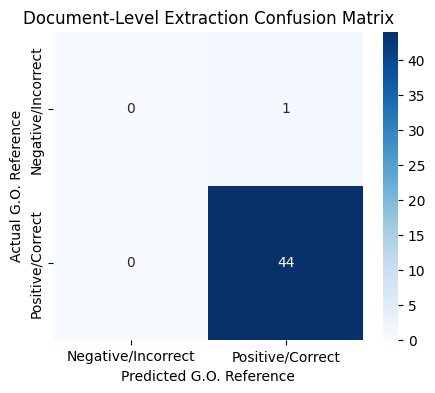

In [13]:
import os
import re
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reconstruct the test split files using the same seed and split indexes
md_files = sorted([f for f in os.listdir('.') if f.endswith('.md')])
md_files = [f for f in md_files if not f.startswith('Project_Report') and f != 'README.md']

random.seed(42)
shuffled_files = md_files.copy()
random.shuffle(shuffled_files)

train_idx = int(len(shuffled_files) * 0.70)
val_idx = train_idx + int(len(shuffled_files) * 0.15)
test_files = shuffled_files[val_idx:]

go_pattern = r'((?:സ\.?\s*ഉ\.?|G\.?\s*O\.?)\s*(?:\([^)]*\))?\s*(?:No\.|No:|No|നം\.?|നം:|നമ്പർ|നന്പർ)?\s*[:.,-]?\s*\d+(?:\s*/\s*[\d()]+)*\s*/\s*[\u0D00-\u0D7FA-Za-z0-9()-]+(?:\.[\u0D00-\u0D7FA-Za-z0-9()-]+)*)'

extractor = GovernmentOrderExtractor('./fine_tuned_model')

comparison_data = []
tp, tn, fp, fn = 0, 0, 0, 0

for filename in test_files:
    with open(filename, 'r', encoding='utf-8') as f:
        content = f.read()
        
    lines = content.split('\n')
    
    # 1. Ground Truth / Regex Reference Extraction
    ref_go = None
    for line in lines[:30]:
        cleaned = line.replace('#', '').replace('*', '').replace('_', '').strip()
        if 'പരാമർശം' in cleaned or 'പരാമർശങ്ങൾ' in cleaned:
            break
        m = re.search(go_pattern, cleaned)
        if m:
            ref_go = m.group(1).strip()
            break
            
    # 2. NER Model Prediction Extraction
    predictions = extractor.extract(content)
    pred_go = predictions.get('go_number', None)
    
    # 3. Compare
    is_match = (ref_go == pred_go)
    
    # Update Confusion Matrix counters
    if ref_go is not None and pred_go is not None:
        if is_match: tp += 1
        else: fp += 1
    elif ref_go is None and pred_go is None:
        tn += 1
    elif ref_go is None and pred_go is not None:
        fp += 1
    elif ref_go is not None and pred_go is None:
        fn += 1
        
    comparison_data.append({
        'Filename': filename,
        'Ground Truth GO Reference': ref_go,
        'Regex Prediction': ref_go,
        'Model Prediction': pred_go,
        'Match': is_match
    })

# Convert to DataFrame
df_comp = pd.DataFrame(comparison_data)

# Calculate metrics
total = len(test_files)
correct = tp + tn
incorrect = fp + fn

accuracy = correct / total if total > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Display evaluation metrics
print("==================================================")
print("     NER Model Test Set Evaluation Metrics        ")
print("==================================================")
print(f"Total Files Evaluated:  {total}")
print(f"Correct Predictions:    {correct}")
print(f"Incorrect Predictions:  {incorrect}")
print(f"Accuracy:               {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precision:              {precision:.4f}")
print(f"Recall:                 {recall:.4f}")
print(f"F1 Score:               {f1:.4f}")
print("--------------------------------------------------")
print("Confusion Summary:")
print(f"  - True Positives (TP):  {tp}")
print(f"  - True Negatives (TN):  {tn}")
print(f"  - False Positives (FP): {fp}")
print(f"  - False Negatives (FN): {fn}")
print("==================================================\n")

# Display comparison table
pd.set_option('display.max_rows', 100)
from IPython.display import display
display(df_comp)

# Generate and display confusion matrix heatmap
cm = np.array([[tn, fp], [fn, tp]])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative/Incorrect', 'Positive/Correct'],
            yticklabels=['Negative/Incorrect', 'Positive/Correct'])
plt.ylabel('Actual G.O. Reference')
plt.xlabel('Predicted G.O. Reference')
plt.title('Document-Level Extraction Confusion Matrix')
plt.show()
